In [1]:
# Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

sys.path.append(os.path.abspath(".."))
from src.preprocessing import preprocess_data

In [2]:
# Load and preprocess data using shared project pipeline
X_train, X_test, y_train, y_test = preprocess_data(
    "../data/online_gaming_behavior_dataset.csv"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

Training shape: (37203, 18)
Testing shape: (8007, 18)

Training class distribution:
EngagementLevel
High      0.333333
Low       0.333333
Medium    0.333333
Name: proportion, dtype: float64


In [3]:
# Baseline SVM (LinearSVC)
baseline_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)
baseline_svm.fit(X_train, y_train)

y_pred_baseline = baseline_svm.predict(X_test)

print("Baseline Accuracy:", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Baseline Weighted F1:", round(f1_score(y_test, y_pred_baseline, average="weighted"), 4))

Baseline Accuracy: 0.7169
Baseline Weighted F1: 0.7145


In [4]:
# Hyperparameter tuning
param_grid = {
    "C": [0.1, 1.0, 5.0, 10.0],
    "class_weight": [None, "balanced"],
    "max_iter": [5000, 10000]
}

grid = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_svm = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Weighted F1:", round(grid.best_score_, 4))

Best Parameters: {'C': 5.0, 'class_weight': None, 'max_iter': 5000}
Best CV Weighted F1: 0.7652


In [5]:
# Evaluate tuned model
y_pred = best_svm.predict(X_test)
decision_scores = best_svm.decision_function(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("========== FINAL SVM EVALUATION ==========")
print(f"Accuracy         : {acc:.4f}")
print(f"Precision        : {prec:.4f}")
print(f"Recall           : {rec:.4f}")
print(f"F1 Score         : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

========== FINAL SVM EVALUATION ==========
Accuracy         : 0.7169
Precision        : 0.7399
Recall           : 0.7169
F1 Score         : 0.7145

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.89      0.81      2067
         Low       0.59      0.77      0.67      2065
      Medium       0.82      0.59      0.69      3875

    accuracy                           0.72      8007
   macro avg       0.72      0.75      0.72      8007
weighted avg       0.74      0.72      0.71      8007



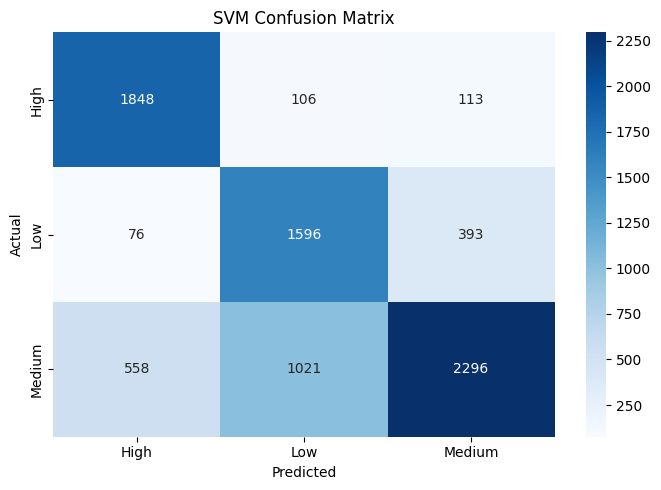

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [7]:
# ROC AUC (One-vs-Rest) using decision scores
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc = roc_auc_score(y_test_bin, decision_scores, average="macro", multi_class="ovr")
print(f"ROC AUC (OvR, macro): {roc_auc:.4f}")

ROC AUC (OvR, macro): 0.8783


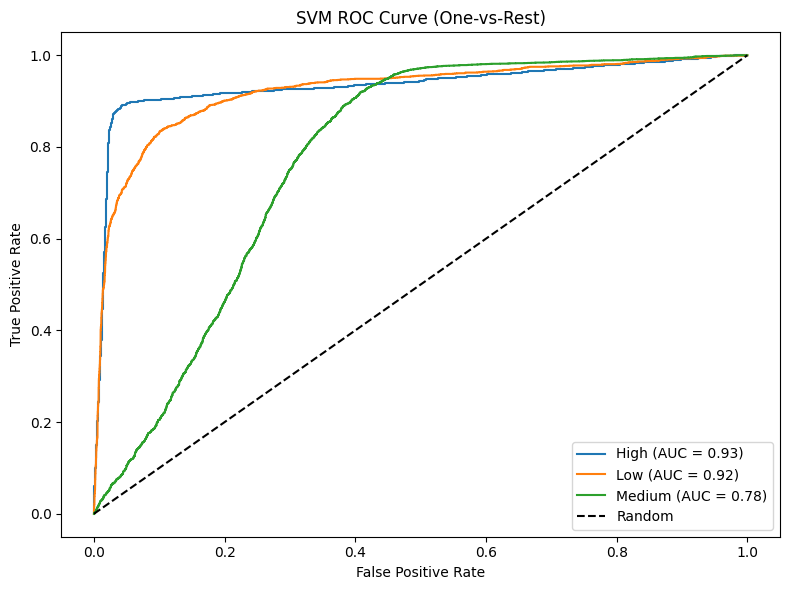

In [8]:
# ROC curves by class
plt.figure(figsize=(8, 6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], decision_scores[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_label} (AUC = {class_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("SVM ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

                      Feature  Importance
7         TotalWeeklyPlayTime    0.929830
3             SessionsPerWeek    0.583071
4   AvgSessionDurationMinutes    0.420173
6        AchievementsUnlocked    0.066457
5                 PlayerLevel    0.055649
9             Location_Europe    0.011088
1               PlayTimeHours    0.009883
0                         Age    0.008293
16        GameDifficulty_Hard    0.006708
11               Location_USA    0.005700


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7348\1576381411.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_k), x="Importance", y="Feature", palette="viridis")


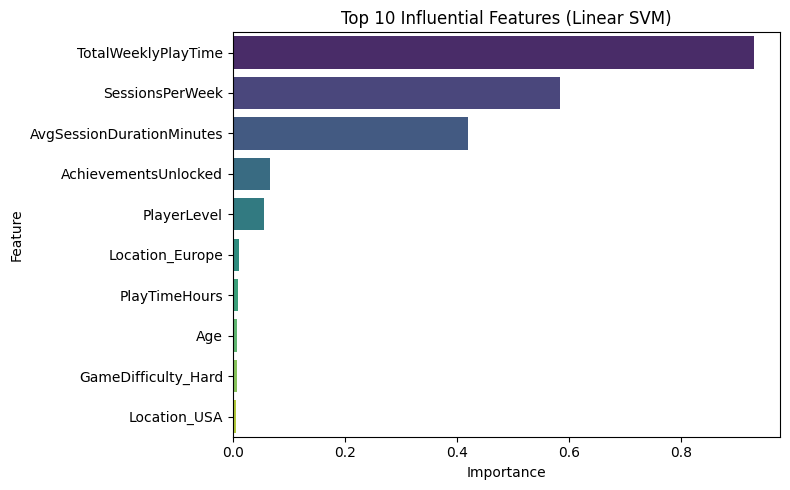

In [9]:
# Interpretability: top features by absolute linear coefficient magnitude
coef_abs_mean = np.mean(np.abs(best_svm.coef_), axis=0)
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": coef_abs_mean
}).sort_values("Importance", ascending=False)

top_k = 10
print(importance_df.head(top_k))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df.head(top_k), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Influential Features (Linear SVM)")
plt.tight_layout()
plt.show()

In [10]:
# Sample prediction table for presentation/demo
sample_n = 12
sample_df = X_test.sample(sample_n, random_state=42).copy()
sample_pred = best_svm.predict(sample_df)

# Use reindexed y_test to align with sampled feature rows
y_test_aligned = y_test.reset_index(drop=True)
sample_actual = y_test_aligned.iloc[sample_df.index]

result_df = pd.DataFrame({
    "Actual": sample_actual.values,
    "Predicted": sample_pred
})
result_df["Correct"] = result_df["Actual"] == result_df["Predicted"]

print(result_df)
print("\nSample Accuracy:", round(result_df["Correct"].mean() * 100, 2), "%")

    Actual Predicted  Correct
0   Medium       Low    False
1     High      High     True
2   Medium    Medium     True
3     High      High     True
4      Low       Low     True
5     High      High     True
6   Medium    Medium     True
7   Medium    Medium     True
8   Medium    Medium     True
9     High      High     True
10    High      High     True
11  Medium    Medium     True

Sample Accuracy: 91.67 %


In [13]:
# Save results to CSV

results = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average='weighted'),
    "Recall": recall_score(y_test, y_pred, average='weighted'),
    "F1-score": f1_score(y_test, y_pred, average='weighted'),
    "ROC_AUC": roc_auc
}

results_df = pd.DataFrame([results])

results_df.to_csv("../results/svm.csv", index=False)